<a href="https://colab.research.google.com/github/udlbook/udlbook/blob/main/Notebooks/Chap10/10_5_Convolution_For_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 10.5: Convolution for MNIST**

This notebook builds a proper network for 2D convolution.  It works with the MNIST dataset (figure 15.15a), which was the original classic dataset for classifying images.  The network will take a 28x28 grayscale image and classify it into one of 10 classes representing a digit.

The code is adapted from https://nextjournal.com/gkoehler/pytorch-mnist

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.


In [1]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import random

In [2]:
# Run this once to load the train and test data straight into a dataloader class
# that will provide the batches

# (It may complain that some files are missing because the files seem to have been
# reorganized on the underlying website, but it still seems to work). If everything is working
# properly, then the whole notebook should run to the end without further problems
# even before you make changes.
batch_size_train = 64
batch_size_test = 1000

# TODO Change this directory to point towards an existing directory
myDir = 'files/'

train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST(myDir, train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST(myDir, train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_test, shuffle=True)

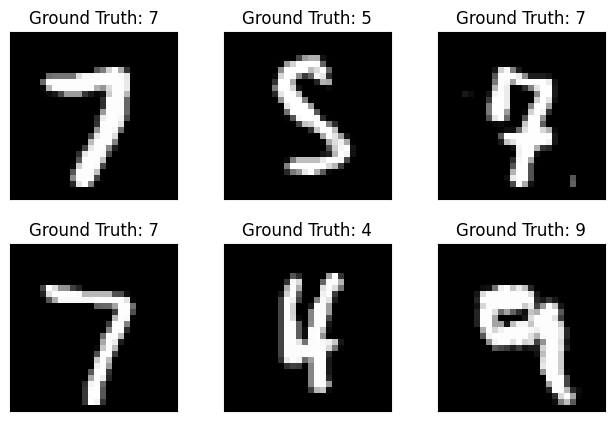

In [3]:
# Let's draw some of the training data
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
plt.show()

Define the network.  This is a more typical way to define a network than the sequential structure.  We define a class for the network, and define the parameters in the constructor.  Then we use a function called forward to actually run the network.  It's easy to see how you might use residual connections in this format.

In [ ]:
from os import X_OK
# TODO Change this class to implement
# 1. A valid convolution with kernel size 5, 1 input channel and 10 output channels
# 2. A max pooling operation over a 2x2 area
# 3. A Relu
# 4. A valid convolution with kernel size 5, 10 input channels and 20 output channels
# 5. A 2D Dropout layer
# 6. A max pooling operation over a 2x2 area
# 7. A relu
# 8. A flattening operation
# 9. A fully connected layer mapping from (whatever dimensions we are at-- find out using .shape) to 50
# 10. A ReLU
# 11. A fully connected layer mapping from 50 to 10 dimensions
# 12. A softmax function.

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Data size is batch_size x 28 x 28

        # 1. A valid convolution with kernel size 5, 1 input channel and 10 output channels
        # Data size is batch_size x 10 x 24 x 24 (we strip 2 pixels on each side)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5)
        # 2. A max pooling operation over a 2x2 area
        # Data size is batch_size 10 x 12 x 12 (we halve each dimension)
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        # 3. A ReLU
        # Data size is batch_size x 10 x 12 x 12 (same size)
        self.relu1 = nn.ReLU(inplace=True)
        # 4. A valid convolution with kernel size 5, 10 input channels and 20 output channels
        # Data size is batch_size x 20 x 8 x 8 (we strip 2 pixels on each side)
        self.conv2 = nn.Conv2d(in_channels=10, out_channels=20, kernel_size=5)
        # 5. A 2D Dropout layer
        # Data size is batch_size x 20 x 8 x 8 (same size)
        self.drop1 = nn.Dropout2d(p=0.5)
        # 6. A max pooling operation over a 2x2 area
        # Data size is batch_size x 20 x 4 x 4 (we halve each dimension)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        # 7. A ReLU
        # Data size is batch_size x 20 x 4 x 4 (same size)
        self.relu2 = nn.ReLU(inplace=True)
        # 8. A flattening operation
        # Data size is batch_size x 320 (20*4*4)
        self.flatten = nn.Flatten()
        # 9. A fully connected layer mapping from 320 to 50
        # Data size is batch_size x 50
        self.fc1 = nn.Linear(in_features=20 * 4 * 4, out_features=50)
        # 10. A ReLU
        # Data size is batch_size x 50 (same size)
        self.relu3 = nn.ReLU(inplace=True)
        # 11. A fully connected layer mapping from 50 to 10 dimensions
        # Data size is batch_size x 10 (number of classes)
        self.fc2 = nn.Linear(in_features=50, out_features=10)
        # 12. A softmax function (use LogSoftmax to pair with F.nll_loss)
        # Data size is batch_size x 10 (same size)
        self.log_softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        # 1. Conv(1→10, k=5)
        x = self.conv1(x)
        # 2. MaxPool 2x2
        x = self.pool1(x)
        # 3. ReLU
        x = self.relu1(x)
        # 4. Conv(10→20, k=5)
        x = self.conv2(x)
        # 5. Dropout2d
        x = self.drop1(x)
        # 6. MaxPool 2x2
        x = self.pool2(x)
        # 7. ReLU
        x = self.relu2(x)
        # 8. Flatten
        x = self.flatten(x)
        # 9. Fully connected to 50
        x = self.fc1(x)
        # 10. ReLU
        x = self.relu3(x)
        # 11. Fully connected to 10
        x = self.fc2(x)
        # 12. Softmax (log)
        x = self.log_softmax(x)
        return x

In [5]:
# He initialization of weights
def weights_init(layer_in):
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform_(layer_in.weight)
    layer_in.bias.data.fill_(0.0)

In [6]:
# Create network
model = Net()
# Initialize model weights
model.apply(weights_init)
# Define optimizer
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)

In [7]:
# Main training routine
def train(epoch):
  model.train()
  # Get each
  for batch_idx, (data, target) in enumerate(train_loader):
    optimizer.zero_grad()
    output = model(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()
    # Store results
    if batch_idx % 10 == 0:
      print('Train Epoch: {} [{}/{}]\tLoss: {:.6f}'.format(
        epoch, batch_idx * len(data), len(train_loader.dataset), loss.item()))

In [8]:
# Run on test data
def test():
  model.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad():
    for data, target in test_loader:
      output = model(data)
      test_loss += F.nll_loss(output, target, size_average=False).item()
      pred = output.data.max(1, keepdim=True)[1]
      correct += pred.eq(target.data.view_as(pred)).sum()
  test_loss /= len(test_loader.dataset)
  print('\nTest set: Avg. loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
    test_loss, correct, len(test_loader.dataset),
    100. * correct / len(test_loader.dataset)))

In [9]:
# Get initial performance
test()
# Train for three epochs
n_epochs = 3
for epoch in range(1, n_epochs + 1):
  train(epoch)
  test()

/home/wiktor/programming/understanding_deep_learning/udlbook/Notebooks/.venv/lib/python3.12/site-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))



Test set: Avg. loss: 2.3879, Accuracy: 939/10000 (9%)

Train Epoch: 1 [0/60000]	Loss: 2.590307
Train Epoch: 1 [640/60000]	Loss: 2.266443
Train Epoch: 1 [1280/60000]	Loss: 2.279258
Train Epoch: 1 [1920/60000]	Loss: 2.161601
Train Epoch: 1 [2560/60000]	Loss: 1.928946
Train Epoch: 1 [3200/60000]	Loss: 1.726341
Train Epoch: 1 [3840/60000]	Loss: 1.814254
Train Epoch: 1 [4480/60000]	Loss: 1.480126
Train Epoch: 1 [5120/60000]	Loss: 1.023850
Train Epoch: 1 [5760/60000]	Loss: 1.161731
Train Epoch: 1 [6400/60000]	Loss: 1.318014
Train Epoch: 1 [7040/60000]	Loss: 0.830265
Train Epoch: 1 [7680/60000]	Loss: 0.899531
Train Epoch: 1 [8320/60000]	Loss: 0.801604
Train Epoch: 1 [8960/60000]	Loss: 0.836394
Train Epoch: 1 [9600/60000]	Loss: 0.718586
Train Epoch: 1 [10240/60000]	Loss: 0.555715
Train Epoch: 1 [10880/60000]	Loss: 0.675734
Train Epoch: 1 [11520/60000]	Loss: 0.630401
Train Epoch: 1 [12160/60000]	Loss: 0.449404
Train Epoch: 1 [12800/60000]	Loss: 0.414569
Train Epoch: 1 [13440/60000]	Loss: 0.392

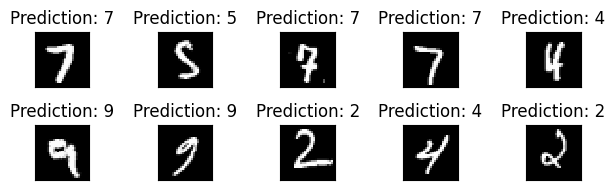

In [10]:
# Run network on data we got before and show predictions
output = model(example_data)

fig = plt.figure()
for i in range(10):
  plt.subplot(5,5,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Prediction: {}".format(
    output.data.max(1, keepdim=True)[1][i].item()))
  plt.xticks([])
  plt.yticks([])
plt.show()